In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import seaborn
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv1D, AveragePooling1D
import tensorflow as tf
from sklearn import metrics

plt.rcParams['font.size'] = 14

2026-03-16 13:40:16.284359: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-16 13:40:16.284587: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-16 13:40:16.319896: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-16 13:40:17.221981: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

In [2]:
# --- Parametri generali dei dati ---
N = 10000       # numero di samples
L = 60          # lunghezza di ciascun time series
Z = 12          # numero di bins del pattern
DX = 50         # rumore
bias = 5        # bias
amp_list = [100, 200, 500, 800]  # ampiezze dei pattern
os.makedirs("DATA", exist_ok=True)

# Parametri CNN
NCONV = 1
NF = 5
BATCH_SIZE = 200
EPOCHS = 150
n_class = 3

# Seed per riproducibilità
np.random.seed(12345)
tf.random.set_seed(12345)

# Label e cmap per confusion matrix
LABELS = ["absent", "positive", "negative"]
cmap = "GnBu"

In [3]:
# --- Funzioni ---
jump = lambda drift, stdev: int(np.random.normal(drift, stdev))
def pattern(i, z, a): return int(a * np.sin((np.pi*i)/z))

def show_confusion_matrix(validations, predictions, label="Model"):
    matrix = metrics.confusion_matrix(validations, predictions)
    plt.figure(figsize=(6,5))
    seaborn.heatmap(matrix, xticklabels=LABELS, yticklabels=LABELS,
                    annot=True, fmt='d', linecolor='white', linewidths=1, cmap=cmap)
    plt.title(f"{label} Confusion Matrix")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()
    
def create_model(input_shape, reg=tf.keras.regularizers.l2(0.2)):
    ini = tf.keras.initializers.RandomNormal(mean=0.0, stddev=0.05)
    model = Sequential()
    if NCONV==1:
        model.add(Conv1D(filters=NF, kernel_size=11, activation='relu',
                         kernel_initializer=ini, kernel_regularizer=reg,
                         input_shape=input_shape))
        model.add(AveragePooling1D(5))
        model.add(Conv1D(filters=5, kernel_size=7, activation='relu'))
        model.add(Flatten())
        model.add(Dense(12, activation='relu'))
        model.add(Dropout(0.2))
    elif NCONV==2:
        model.add(Conv1D(filters=NF, kernel_size=11, activation='relu',
                         kernel_initializer=ini, kernel_regularizer=reg,
                         input_shape=input_shape))
        model.add(AveragePooling1D(5))
        model.add(Flatten())
        model.add(Dense(9, activation='relu'))
        model.add(Dropout(0.2))
        model.add(Dense(6, activation='relu'))
        model.add(Dropout(0.2))
    model.add(Dense(n_class, activation='softmax'))
    model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

def preprocess_data(x, y, train_frac=0.8):
    # one-hot encoding
    y_oh = np.zeros((len(y), n_class))
    for i in range(len(y)):
        y_oh[i][y[i]] = 1.
    # split train/val
    N_train = int(train_frac * len(x))
    x_train, y_train = x[:N_train], y_oh[:N_train]
    x_val, y_val = x[N_train:], y_oh[N_train:]
    # rescale
    std_mean = x_train.std(axis=1).mean()
    x_train = (x_train - x_train.mean(axis=1)[:,None]) / std_mean
    x_val = (x_val - x_val.mean(axis=1)[:,None]) / std_mean
    # reshape
    x_train = x_train.reshape(x_train.shape[0], L, 1)
    x_val = x_val.reshape(x_val.shape[0], L, 1)
    return x_train, y_train, x_val, y_val


def show_history(fit, label="Model"):
    """Mostra i grafici di Accuracy e Loss"""
    fig, AX = plt.subplots(1, 2, figsize=(12,5))
    
    # Accuracy
    ax = AX[0]
    ax.plot(fit.history['accuracy'], "b", label="train")
    ax.plot(fit.history['val_accuracy'], "r--", label="valid.")
    ax.axhline(1/n_class, color='gray', linestyle=':', label="random chance")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Accuracy")
    ax.set_ylim([0, 1])
    ax.set_title(f"{label} - Accuracy")
    ax.legend()
    
    # Loss
    ax = AX[1]
    ax.plot(fit.history['loss'], "b", label="train")
    ax.plot(fit.history['val_loss'], "r--", label="valid.")
    ax.set_xlabel('epoch')
    ax.set_ylabel("Loss")
    ax.set_ylim([0, 1.05*np.max(fit.history['loss'])])
    ax.set_title(f"{label} - Loss")
    ax.legend()
    
    plt.show()
    
    



===== Dataset e CNN con ampiezza A=100 =====


/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-03-16 13:40:18.078416: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


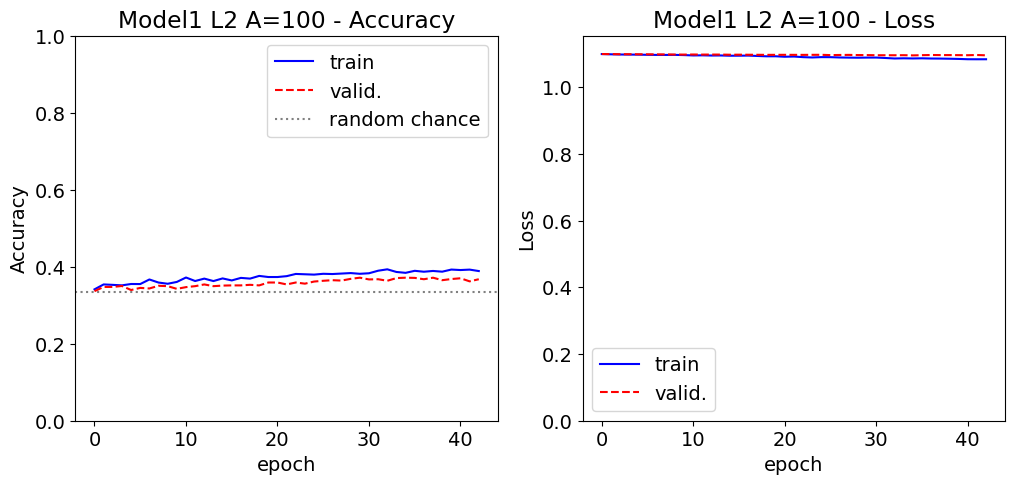

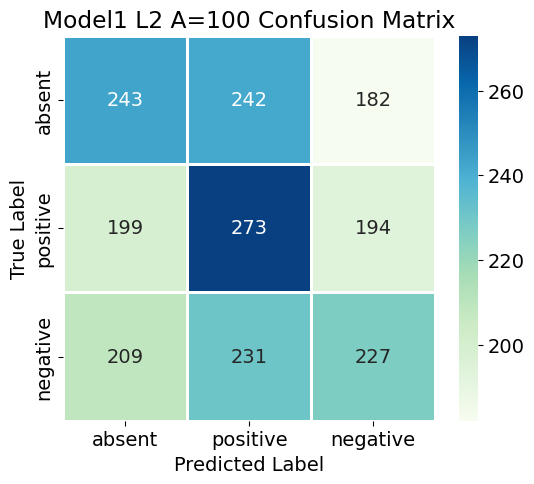

/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


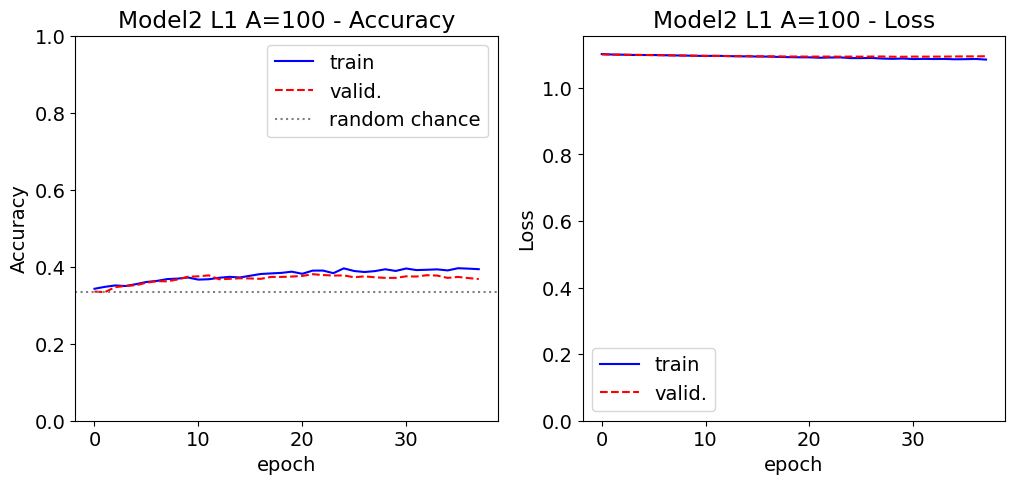

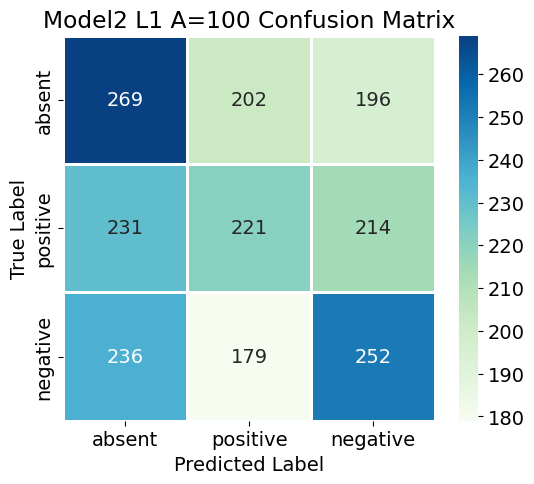

Validation accuracy Model1 L2 A=100: 0.368
Validation accuracy Model2 L1 A=100: 0.368

===== Dataset e CNN con ampiezza A=200 =====


/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


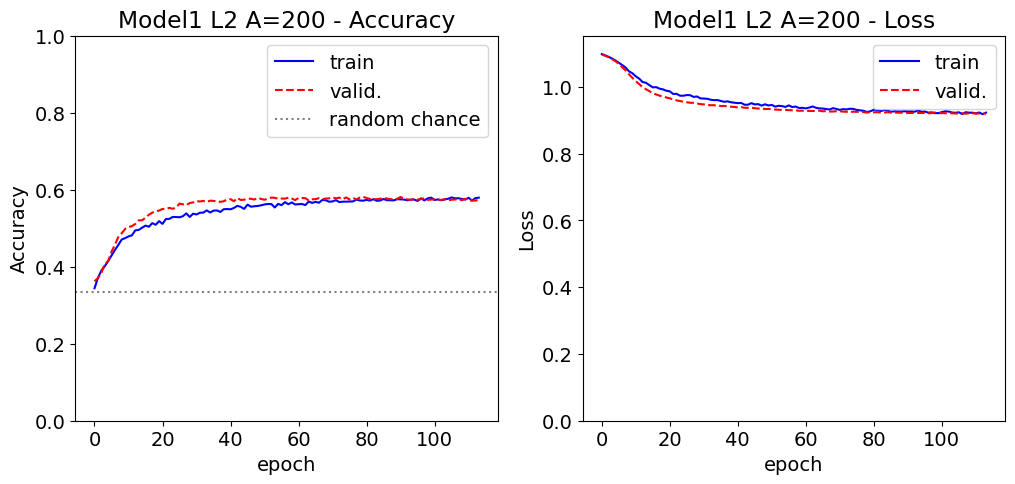

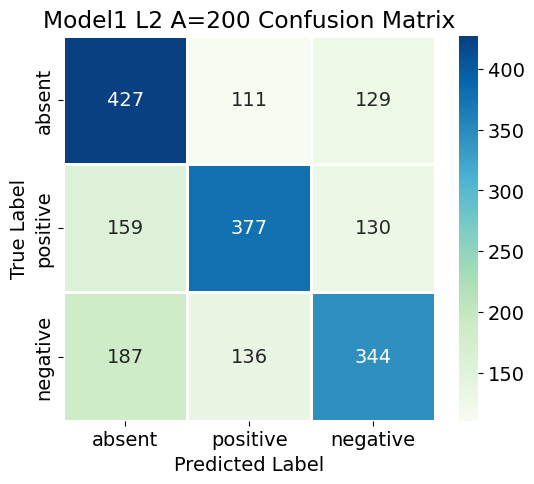

/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


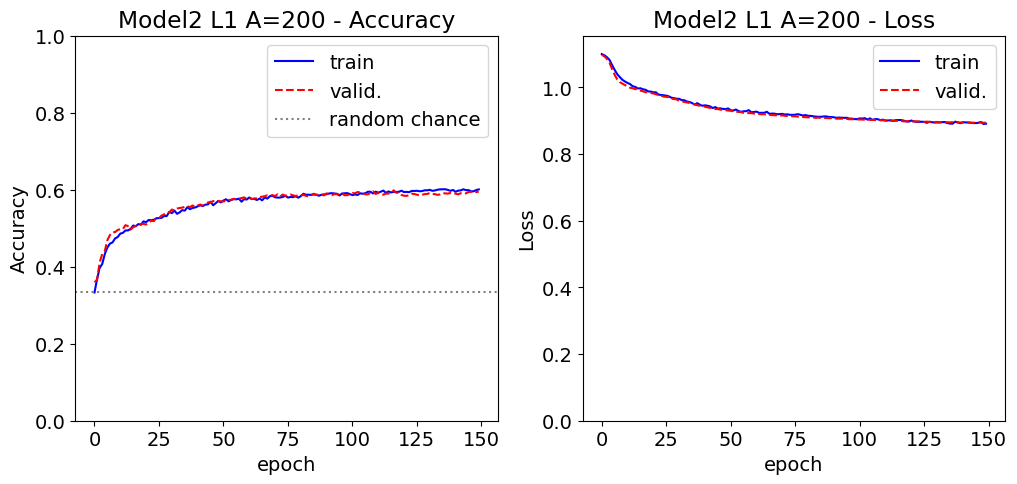

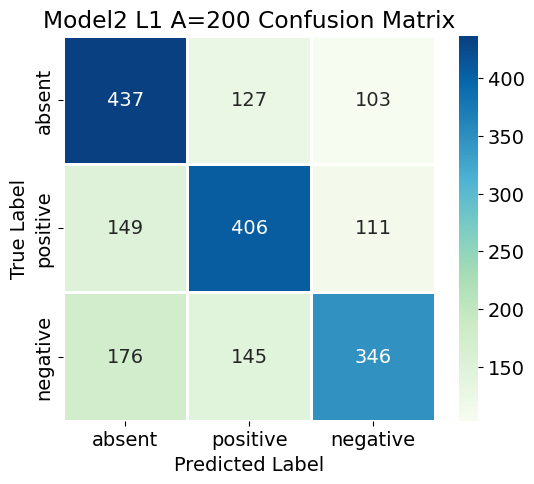

Validation accuracy Model1 L2 A=200: 0.575
Validation accuracy Model2 L1 A=200: 0.595

===== Dataset e CNN con ampiezza A=500 =====


/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


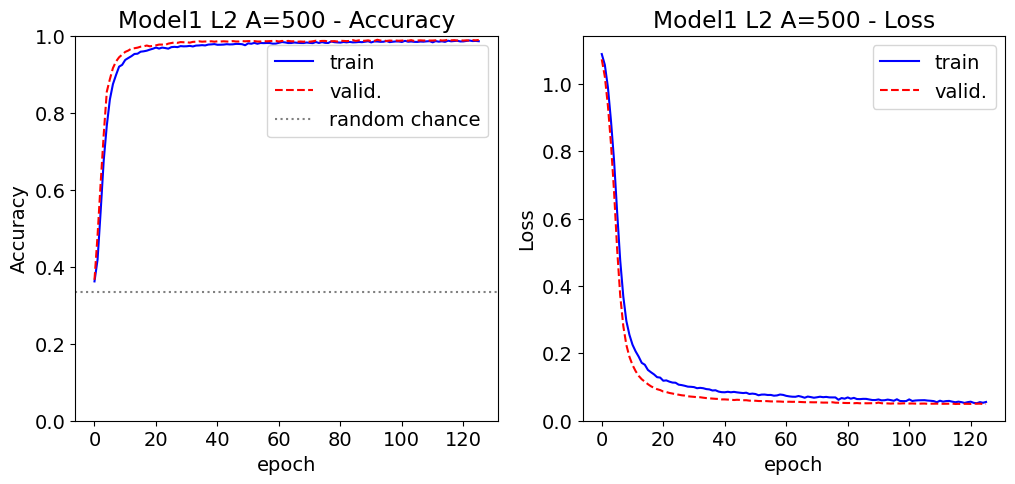

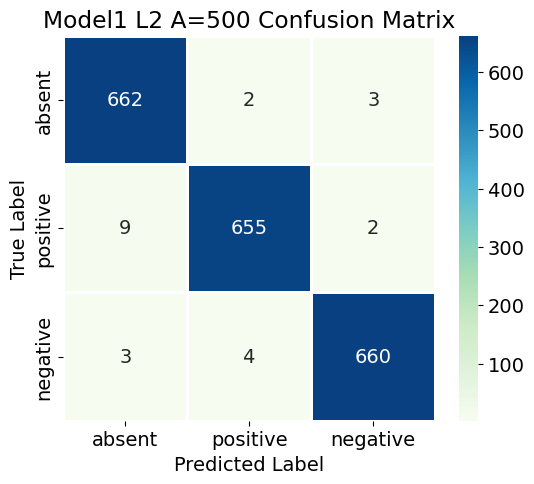

/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


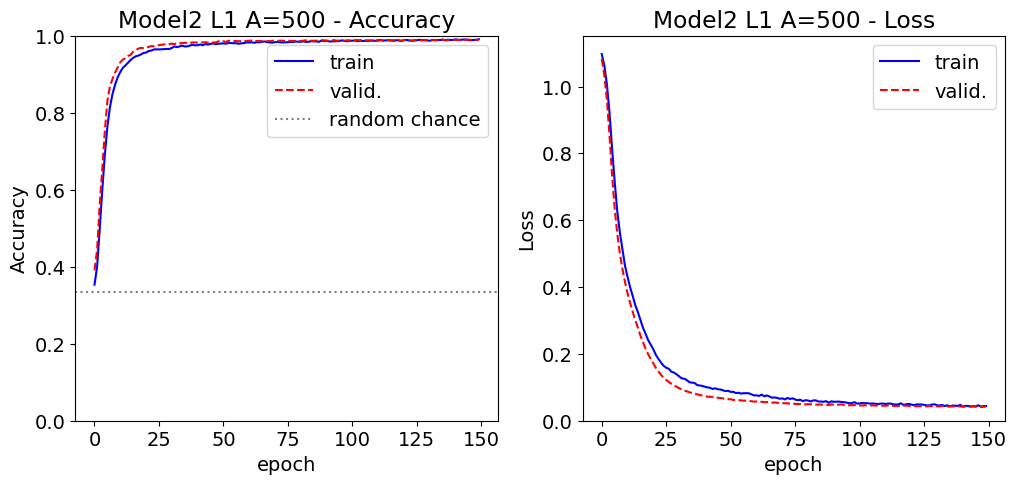

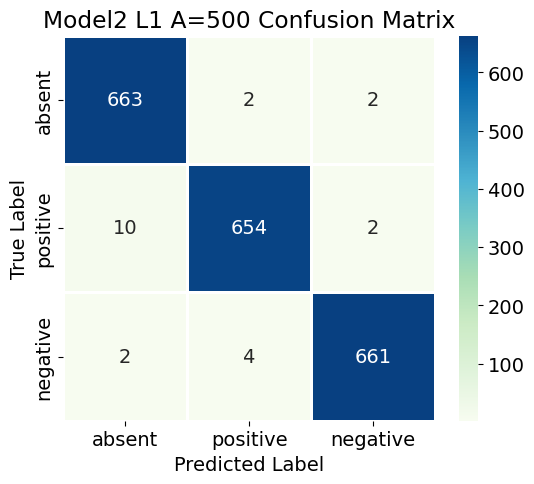

Validation accuracy Model1 L2 A=500: 0.989
Validation accuracy Model2 L1 A=500: 0.989

===== Dataset e CNN con ampiezza A=800 =====


/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


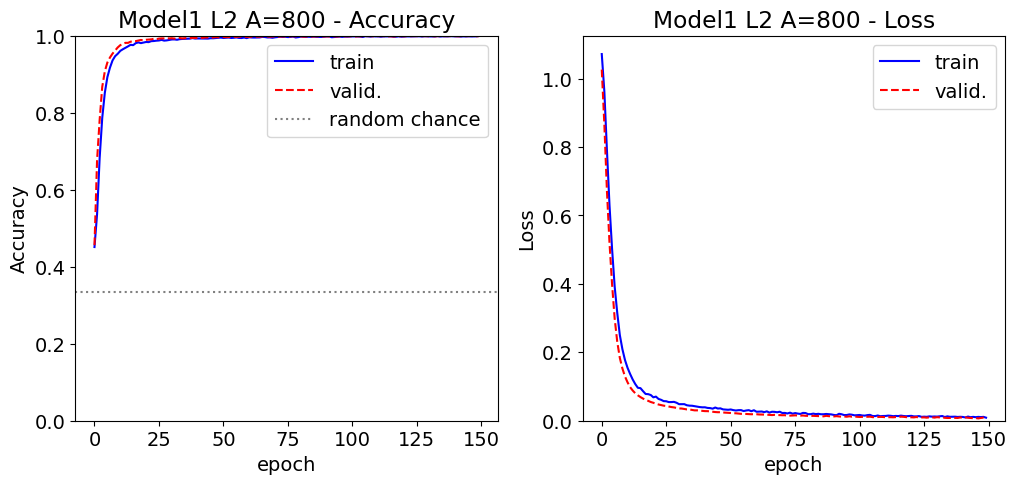

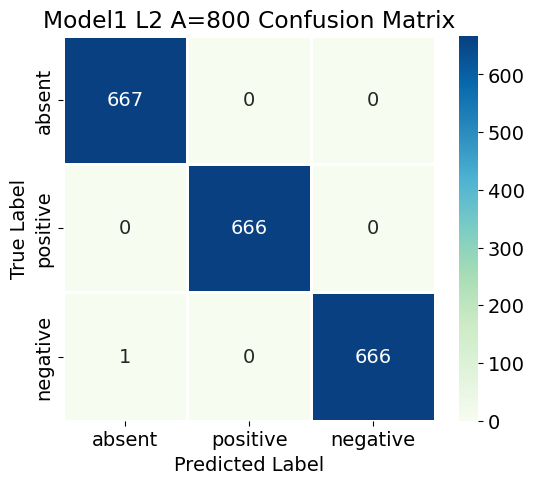

/home/sara/anaconda3/lib/python3.9/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


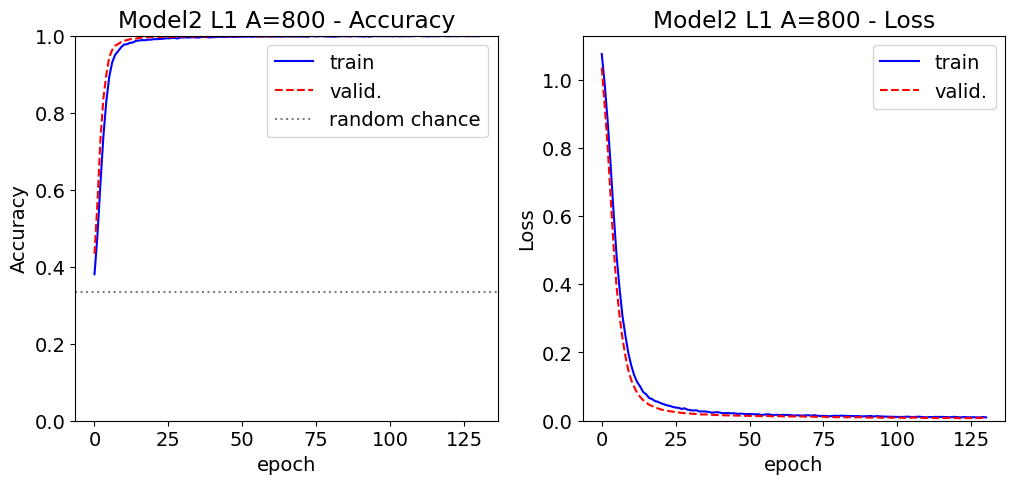

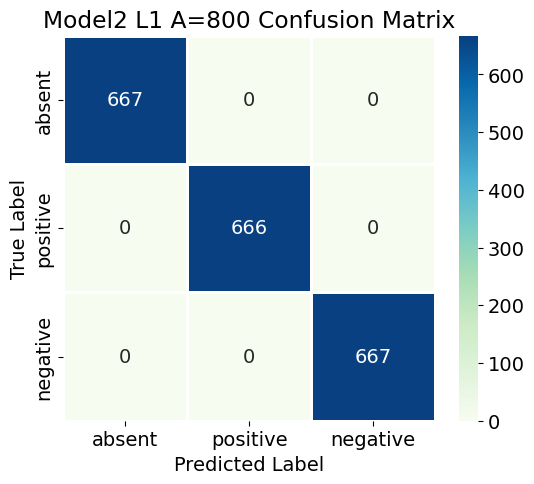

Validation accuracy Model1 L2 A=800: 0.999
Validation accuracy Model2 L1 A=800: 0.999


In [4]:
# --- Loop sulle ampiezze ---
for A in amp_list:
    print(f"\n===== Dataset e CNN con ampiezza A={A} =====")
    
    # nomi file
    str0 = f'ts_L{L}_Z{Z}_A{A}_DX{DX}_bias{bias}_N{N}.dat'
    fnamex = 'DATA/x_' + str0
    fnamey = 'DATA/y_' + str0
    
    # --- Genera dati ---
    x = [[0] * L for _ in range(N)]
    y = [0] * N

    for i in range(N):
        if i > 0:
            x[i][0] = x[i-1][-1] + jump(bias, DX)
        for j in range(1, L):
            x[i][j] = x[i][j-1] + jump(bias, DX)
        y[i] = i % 3
        if y[i] > 0:
            j0 = np.random.randint(0, L-1-Z)
            sign = 3 - 2*y[i]  # +1 for class 1, -1 for class 2
            for j in range(Z):
                x[i][j0 + j] += sign * pattern(j, Z, A)

    x = np.array(x, dtype=float)
    y = np.array(y, dtype=int)

    #salva i dataset su file
    np.savetxt(fnamex, x, fmt="%d")
    np.savetxt(fnamey, y, fmt="%d")
    
    # one-hot encoding
    y_oh = np.zeros((len(y), n_class))
    for i in range(len(y)):
        y_oh[i][y[i]] = 1.
    
    # split train/val
    N_train = int(0.8*len(x))
    x_train, y_train = x[:N_train], y_oh[:N_train]
    x_val, y_val = x[N_train:], y_oh[N_train:]
    
    # rescale con std media del train
    std_mean = x_train.std(axis=1).mean()
    x_train = (x_train - x_train.mean(axis=1)[:, None]) / std_mean
    x_val = (x_val - x_val.mean(axis=1)[:, None]) / std_mean
    
    # reshape per CNN
    x_train = x_train.reshape(N_train, L, 1)
    x_val = x_val.reshape(len(x)-N_train, L, 1)
    
    early = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        mode="min",
        patience=8,
        restore_best_weights=True
    )
    
    # --- Modello 1: L2 ---
    reg_l2 = tf.keras.regularizers.l2(0.01)

    model1 = create_model((L,1), reg_l2)

    fit1 = model1.fit(x_train, y_train,  batch_size=BATCH_SIZE, epochs=EPOCHS, validation_data=(x_val, y_val),
                      verbose=0,callbacks=[early])

    # predizione
    y_pred_val1 = np.argmax(model1.predict(x_val), axis=1)
    y_val_true = np.argmax(y_val, axis=1)

    show_history(fit1, label=f"Model1 L2 A={A}")
    show_confusion_matrix(y_val_true, y_pred_val1, label=f"Model1 L2 A={A}")


    # --- Modello 2: L1 ---
    reg_l1 = tf.keras.regularizers.l1(0.001)

    model2 = create_model((L,1), reg_l1)

    fit2 = model2.fit(x_train,  y_train,  batch_size=BATCH_SIZE,  epochs=EPOCHS,  validation_data=(x_val, y_val),
                      verbose=0,callbacks=[early])

    # predizione
    y_pred_val2 = np.argmax(model2.predict(x_val), axis=1)

    show_history(fit2, label=f"Model2 L1 A={A}")
    show_confusion_matrix(y_val_true, y_pred_val2, label=f"Model2 L1 A={A}")


    # stampa accuracy finale
    print(f"Validation accuracy Model1 L2 A={A}: {fit1.history['val_accuracy'][-1]:.3f}")
    print(f"Validation accuracy Model2 L1 A={A}: {fit2.history['val_accuracy'][-1]:.3f}")